# Official HEC-HMS Guide Mirror: Basin Methods, Loss, Transform, Baseflow, and Routing

Official guides:

- https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/parameter-estimation
- https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/applying-loss-methods-in-hec-hms
- https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/applying-transform-methods-in-hec-hms
- https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/applying-baseflow-methods-in-hec-hms
- https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/applying-reach-routing-methods-within-hec-hms

This notebook inspects the basin parameters manipulated in those GUI workflows and adds visual checks for SCS curve-number sensitivity, a unit hydrograph shape, and routed inflow/outflow attenuation.

## HEC-HMS Documentation Alignment

| Notebook checkpoint | HEC-HMS reference |
|---|---|
| Method families on hydrologic elements | [User's Manual: Application Steps](https://www.hec.usace.army.mil/confluence/hmsdocs/hmsum/latest/overview/application-steps) |
| Loss method selection and parameter editors | [User's Manual: Selecting a Loss Method](https://www.hec.usace.army.mil/confluence/hmsdocs/hmsum/latest/subbasin-elements/selecting-a-loss-method) |
| Transform method theory | [Technical Reference: Available Transform Methods](https://www.hec.usace.army.mil/confluence/hmsdocs/hmstrm/transform/available-transform-methods) |
| Baseflow method selection | [User's Manual: Selecting a Baseflow Method](https://www.hec.usace.army.mil/confluence/hmsdocs/hmsum/latest/subbasin-elements/selecting-a-baseflow-method) |
| Reach routing method theory | [Technical Reference: Available Channel Routing Methods](https://www.hec.usace.army.mil/confluence/hmsdocs/hmstrm/channel-flow/available-channel-routing-methods) |


In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

logging.disable(logging.CRITICAL)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "hms_commander").is_dir() and (candidate / "examples").is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
WORK_ROOT = REPO_ROOT / "examples" / "working" / "clb238_guides"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
HMS_VERSION = "4.13"

from hms_commander import HmsExamples, HmsPrj

available_versions = HmsExamples.list_versions()
if HMS_VERSION not in available_versions:
    HMS_VERSION = available_versions[0]
HMS_EXE = HmsExamples.get_hms_exe(HMS_VERSION)


def init_sample_project(project_name, notebook_key, overwrite=True):
    project_path = HmsExamples.extract_project(
        project_name,
        version=HMS_VERSION,
        output_path=WORK_ROOT / notebook_key,
        overwrite=overwrite,
    )
    project = HmsPrj()
    project.initialize(project_path, hms_exe_path=HMS_EXE)
    return project, project_path

In [2]:
from hms_commander import HmsBasin, HmsCmdr, HmsDss, HmsUtils

project, project_path = init_sample_project("castro", "104_basin_methods")
run_name = "Current"
config = project.get_run_configuration(run_name)
basin_path = Path(config["basin_file"])

loss = HmsBasin.get_all_loss_parameters(basin_path)
transform = HmsBasin.get_all_transform_parameters(basin_path)
baseflow = HmsBasin.get_all_baseflow_parameters(basin_path)
routing = HmsBasin.get_all_routing_parameters(basin_path)

method_summary = pd.DataFrame([
    {"category": "loss", "elements": len(loss), "methods": ", ".join(sorted(loss["loss_method"].dropna().astype(str).unique()))},
    {"category": "transform", "elements": len(transform), "methods": ", ".join(sorted(transform["transform_method"].dropna().astype(str).unique()))},
    {"category": "baseflow", "elements": len(baseflow), "methods": ", ".join(sorted(baseflow["baseflow_method"].dropna().astype(str).unique()))},
    {"category": "routing", "elements": len(routing), "methods": ", ".join(sorted(routing["route_method"].dropna().astype(str).unique()))},
])
assert method_summary["elements"].sum() > 0
method_summary

,category,elements,methods
0,loss,4,Initial+Constant
1,transform,4,Snyder
2,baseflow,4,Recession
3,routing,2,"Modified Puls, Muskingum"


In [3]:
# CLB-653 basin parameter overview table
def keep_columns(df, columns):
    return df[[col for col in columns if col in df.columns]].copy()


loss_view = keep_columns(loss, [
    "name", "area", "loss_method", "percent_impervious", "initial_loss", "constant_rate", "curve_number",
])
transform_view = keep_columns(transform, [
    "name", "transform_method", "snyder_tp", "snyder_cp", "time_of_concentration", "storage_coefficient", "lag",
])
baseflow_view = keep_columns(baseflow, [
    "name", "baseflow_method", "recession_factor", "initial_discharge", "threshold_flow", "threshold_ratio",
])
routing_view = keep_columns(routing, [
    "name", "route_method", "number_of_reaches", "muskingum_k", "muskingum_x", "lag",
])

subbasin_parameter_overview = (
    loss_view
    .merge(transform_view, on="name", how="outer")
    .merge(baseflow_view, on="name", how="outer")
    .sort_values("name")
    .reset_index(drop=True)
)
reach_parameter_overview = routing_view.sort_values("name").reset_index(drop=True)

display(method_summary)
display(subbasin_parameter_overview.fillna(""))
display(reach_parameter_overview.fillna(""))


,category,elements,methods
0,loss,4,Initial+Constant
1,transform,4,Snyder
2,baseflow,4,Recession
3,routing,2,"Modified Puls, Muskingum"


,name,area,loss_method,percent_impervious,initial_loss,constant_rate,curve_number,transform_method,snyder_tp,snyder_cp,time_of_concentration,storage_coefficient,lag,baseflow_method,recession_factor,initial_discharge,threshold_flow,threshold_ratio
0,Subbasin-1,0.86,Initial+Constant,2.0,0.02,,,Snyder,0.20,0.16,,,,Recession,0.79,,,
1,Subbasin-2,1.52,Initial+Constant,8.0,0.02,,,Snyder,0.28,0.16,,,,Recession,0.79,,,
2,Subbasin-3,2.17,Initial+Constant,10.0,0.02,,,Snyder,0.20,0.16,,,,Recession,0.79,,,
3,Subbasin-4,0.96,Initial+Constant,15.0,0.02,,,Snyder,0.17,0.16,,,,Recession,0.79,,,


,name,route_method,number_of_reaches,muskingum_k,muskingum_x,lag
0,Reach-1,Muskingum,,0.6,0.2,
1,Reach-2,Modified Puls,4.0,,,


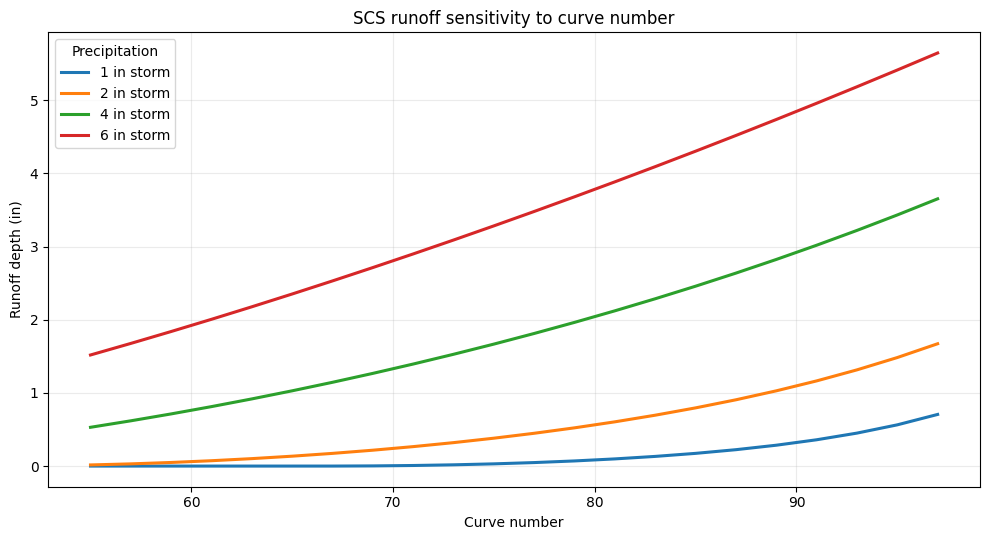

,curve_number,runoff_1in,runoff_2in,runoff_4in,runoff_6in
17,89,0.284962,1.027963,2.823059,4.735431
18,91,0.359267,1.163624,3.017340,4.957218
19,93,0.450386,1.314494,3.219877,5.182586
20,95,0.563353,1.482838,3.431078,5.411562
21,97,0.705547,1.671427,3.651386,5.644177


In [4]:
curve_numbers = np.arange(55, 99, 2)
storm_depths = [1.0, 2.0, 4.0, 6.0]

def scs_runoff_depth(precip_in, curve_number):
    storage = (1000.0 / curve_number) - 10.0
    initial_abstraction = HmsUtils.calculate_ia_from_cn(float(curve_number))
    if precip_in <= initial_abstraction:
        return 0.0
    return ((precip_in - initial_abstraction) ** 2) / (precip_in - initial_abstraction + storage)

sensitivity = pd.DataFrame({"curve_number": curve_numbers})
for depth in storm_depths:
    sensitivity[f"runoff_{depth:.0f}in"] = [scs_runoff_depth(depth, cn) for cn in curve_numbers]

fig, ax = plt.subplots(figsize=(10, 5.5))
for depth in storm_depths:
    ax.plot(
        sensitivity["curve_number"],
        sensitivity[f"runoff_{depth:.0f}in"],
        linewidth=2.2,
        label=f"{depth:.0f} in storm",
    )
ax.set_title("SCS runoff sensitivity to curve number")
ax.set_xlabel("Curve number")
ax.set_ylabel("Runoff depth (in)")
ax.grid(True, alpha=0.25)
ax.legend(title="Precipitation")
plt.tight_layout()
plt.show()

sensitivity.tail()

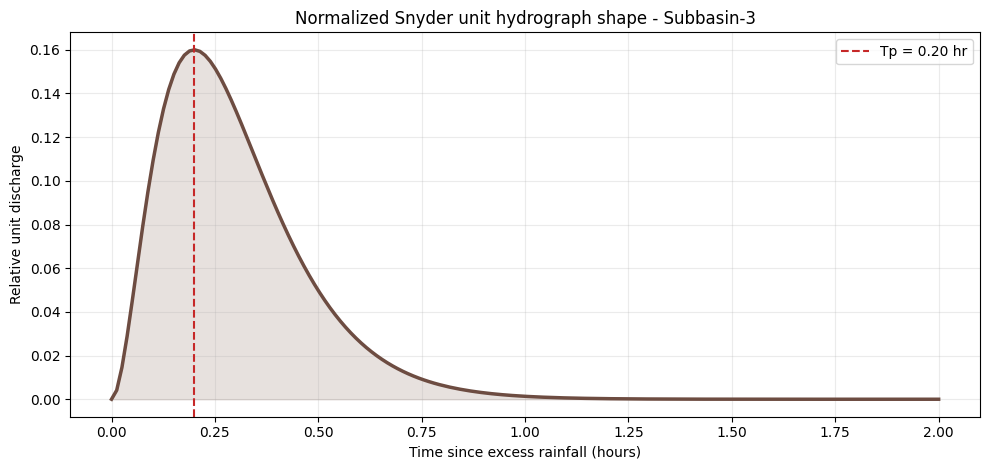

,subbasin,snyder_tp_hr,snyder_cp,peak_relative_discharge
0,Subbasin-3,0.2,0.16,0.16


In [5]:
snyder_row = transform.dropna(subset=["snyder_tp", "snyder_cp"]).iloc[0]
tp = float(snyder_row["snyder_tp"])
cp = float(snyder_row["snyder_cp"])
unit_time = np.linspace(0, max(2.0, tp * 8), 160)
dimensionless = np.where(unit_time > 0, (unit_time / tp) ** 2 * np.exp(2 * (1 - unit_time / tp)), 0.0)
unit_shape = cp * dimensionless / dimensionless.max()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(unit_time, unit_shape, color="#6d4c41", linewidth=2.5)
ax.fill_between(unit_time, unit_shape, color="#a1887f", alpha=0.25)
ax.axvline(tp, color="#c62828", linestyle="--", label=f"Tp = {tp:.2f} hr")
ax.set_title(f"Normalized Snyder unit hydrograph shape - {snyder_row['name']}")
ax.set_xlabel("Time since excess rainfall (hours)")
ax.set_ylabel("Relative unit discharge")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame([{
    "subbasin": snyder_row["name"],
    "snyder_tp_hr": tp,
    "snyder_cp": cp,
    "peak_relative_discharge": round(float(unit_shape.max()), 3),
}])

Configuring Java VM for DSS operations...
  Found Java: C:\Program Files\HEC\HEC-HMS\4.9\jre
[OK] Java VM configured


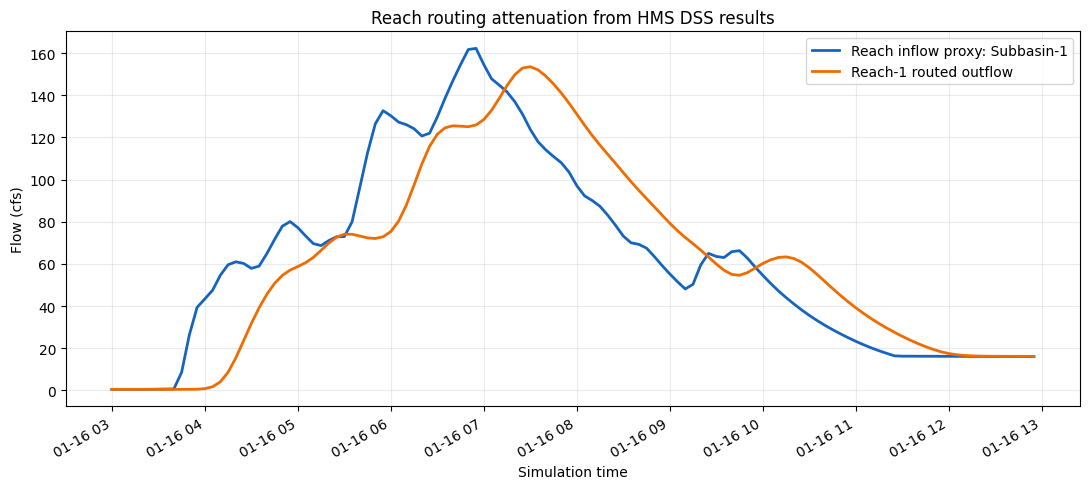

,inflow_peak_cfs,outflow_peak_cfs,peak_reduction_pct,inflow_peak_time,outflow_peak_time
0,162.3,153.6,5.4,1973-01-16 06:55:00,1973-01-16 07:30:00


In [6]:
success = HmsCmdr.compute_run(
    run_name,
    hms_object=project,
    timeout=120,
    save_project=False,
    max_memory="2G",
)
assert success

dss_file = project_path / config["dss_file"]
catalog = HmsDss.get_catalog(dss_file)
inflow_path = next(path for path in catalog if "//SUBBASIN-1/FLOW/" in path.upper())
outflow_path = next(path for path in catalog if "//REACH-1/FLOW/" in path.upper())
inflow = HmsDss.read_timeseries(dss_file, inflow_path)
outflow = HmsDss.read_timeseries(dss_file, outflow_path)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(inflow.index, inflow["value"], color="#1565c0", linewidth=2, label="Reach inflow proxy: Subbasin-1")
ax.plot(outflow.index, outflow["value"], color="#ef6c00", linewidth=2, label="Reach-1 routed outflow")
ax.set_title("Reach routing attenuation from HMS DSS results")
ax.set_xlabel("Simulation time")
ax.set_ylabel("Flow (cfs)")
ax.grid(True, alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

routing_summary = pd.DataFrame([{
    "inflow_peak_cfs": round(float(inflow["value"].max()), 1),
    "outflow_peak_cfs": round(float(outflow["value"].max()), 1),
    "peak_reduction_pct": round((1 - outflow["value"].max() / inflow["value"].max()) * 100, 1),
    "inflow_peak_time": inflow["value"].idxmax(),
    "outflow_peak_time": outflow["value"].idxmax(),
}])
routing_summary

In [7]:
export_csv = WORK_ROOT / "104_basin_methods" / "parameter_exports" / "castro_parameters.csv"
export_csv.parent.mkdir(parents=True, exist_ok=True)
combined_csv = HmsBasin.export_parameters_csv(basin_path, export_csv)
exported_files = sorted(export_csv.parent.glob("castro_parameters*.csv"))
export_summary = pd.DataFrame([
    {"file": path.name, "exists": path.exists(), "size_kb": round(path.stat().st_size / 1024, 1)}
    for path in exported_files
])
assert combined_csv.exists()
assert len(export_summary) >= 4
export_summary

,file,exists,size_kb
0,castro_parameters.csv,True,1.2
1,castro_parameters_baseflow.csv,True,0.8
2,castro_parameters_loss.csv,True,0.8
3,castro_parameters_routing.csv,True,0.7
4,castro_parameters_transform.csv,True,0.5


## Coverage Notes

This notebook validates the existing parameter inventory/export surface and adds visual hydrologic checks. The Snyder shape is generated from parsed HMS transform parameters because the current DSS reader does not expose HMS unit-graph pattern records as ordinary time series.

## What You Should See in the HMS GUI

Select each Castro subbasin in the Basin Model Map or Watershed Explorer. The Loss, Transform, and Baseflow editors should match the subbasin parameter overview table. Select each reach to verify the routing methods and parameters shown in the reach table, then compare the Results tab reach outflow plot with the routed attenuation figure.
